<a href="https://colab.research.google.com/github/Nguyen-Quoc-An/TH_DeepLearning/blob/main/Lab4_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import pandas as pd
import numpy as np
import tensorflow as tf
import keras
from keras.layers import Conv2D, Dense, MaxPool2D, Flatten
from keras.models import Sequential
from keras import Input
#data visualization packages
import matplotlib.pyplot as plt

In [21]:
mnist_train ='/content/sample_data/mnist_train_small.csv'
mnist_test ='/content/sample_data/mnist_test.csv'
df_train = pd.read_csv(mnist_train)
df_test = pd.read_csv(mnist_test)

print(df_train.shape)
X_train = df_train.iloc[:,1:]
y_train = df_train.iloc[:,0]
X_test = df_test.iloc[:,1:]
y_test = df_test.iloc[:,0]
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(19999, 785)
(19999, 784) (19999,) (9999, 784) (9999,)


In [22]:
num_classes = 10
input_shape = (28, 28, 1)
X_train = X_train.astype("float32")/255
X_test = X_test.astype("float32")/255
X_train = X_train.to_numpy()
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
print(X_train.shape)
X_test = X_test.to_numpy()
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)
print(X_test.shape)


print('Number of classes:', len(np.unique(y_train)))
print('Classes:', np.unique(y_train))
print(y_train[:5])

(19999, 28, 28, 1)
(9999, 28, 28, 1)
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]
0    5
1    7
2    9
3    5
4    2
Name: 6, dtype: int64


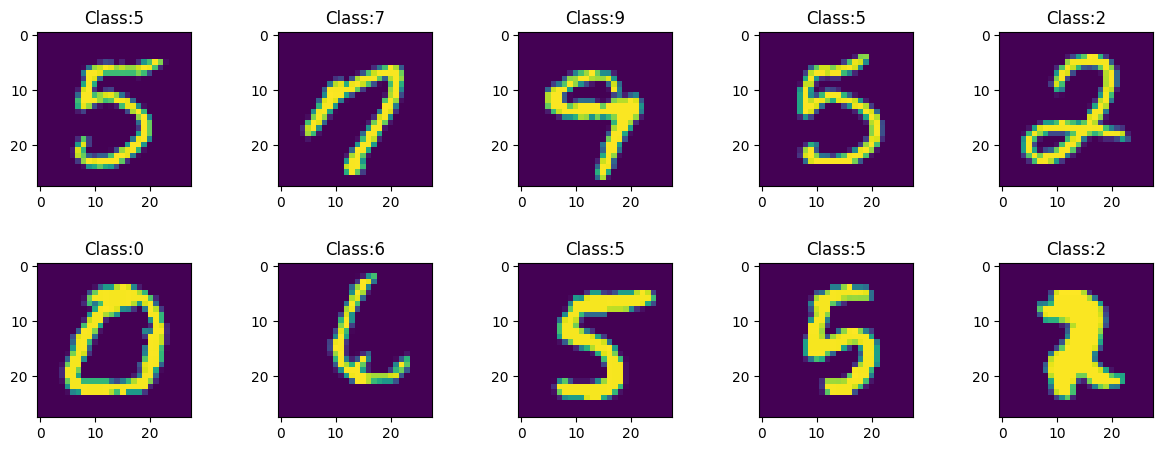

In [23]:

fig, axes = plt.subplots(nrows=2, ncols=5,figsize=(15, 5))
ax = axes.ravel()
for i in range(10):
    ax[i].imshow(X_train[i].reshape(28, 28))
    ax[i].title.set_text('Class:'+str(y_train[i]))
plt.subplots_adjust(hspace=0.5)
plt.show()

In [24]:
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

In [25]:
model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3, 3), activation="relu"))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Conv2D(64, kernel_size=(3, 3), activation="relu"))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(units=10, activation="softmax"))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_fit = model.fit(X_train, y_train, batch_size=128, epochs=15, validation_split=0.1, verbose=1)

Epoch 1/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 14s 90ms/step - accuracy: 0.8277 - loss: 0.6225 - val_accuracy: 0.9330 - val_loss: 0.2248
Epoch 2/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 21s 92ms/step - accuracy: 0.9542 - loss: 0.1545 - val_accuracy: 0.9575 - val_loss: 0.1369
Epoch 3/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 16s 111ms/step - accuracy: 0.9688 - loss: 0.1031 - val_accuracy: 0.9645 - val_loss: 0.1019
Epoch 4/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 12s 88ms/step - accuracy: 0.9747 - loss: 0.0803 - val_accuracy: 0.9705 - val_loss: 0.0960
Epoch 5/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 21s 90ms/step - accuracy: 0.9808 - loss: 0.0630 - val_accuracy: 0.9735 - val_loss: 0.0793
Epoch 6/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 15s 104ms/step - accuracy: 0.9837 - loss: 0.0549 - val_accuracy: 0.9690 - val_loss: 0.0924
Epoch 7/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 12s 87ms/step - accuracy: 0.9865 - loss: 0.0456 - val_accuracy: 0.9740 - val_loss: 0.0886
Epoch 8/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 24s 115ms/step - accuracy: 0.9877 - loss: 0.0386

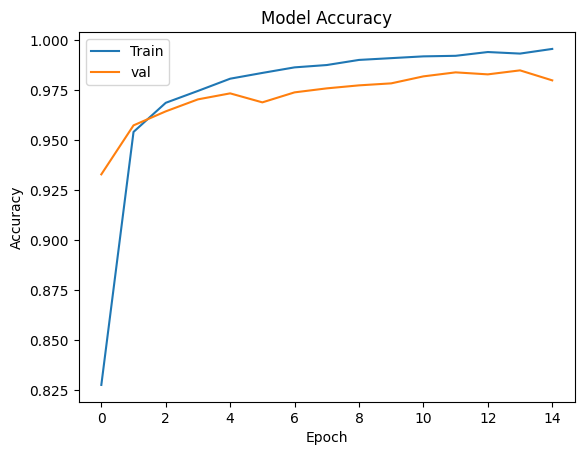

In [27]:
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'val'], loc='upper left')
plt.show()

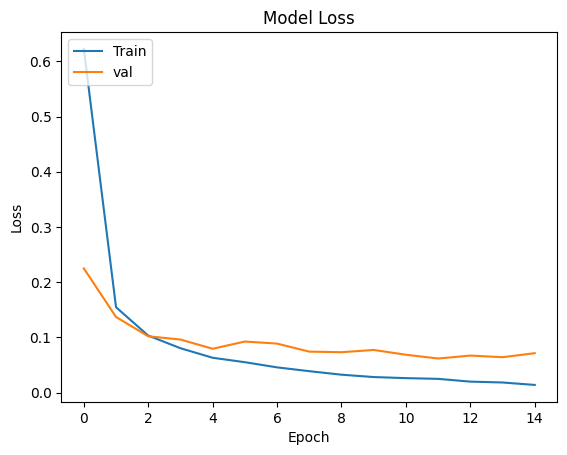

In [28]:
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'val'], loc='upper left')
plt.show()

In [29]:
score = model.evaluate(X_test, y_test, verbose=2)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

313/313 - 2s - 7ms/step - accuracy: 0.9828 - loss: 0.0562
Test loss: 0.05622699856758118
Test accuracy: 0.9827982783317566


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
[[2.7750604e-04 2.0617975e-03 9.9765849e-01 1.8342315e-09 1.4737681e-16
  5.8415848e-13 2.0987127e-06 6.7391443e-17 1.1861079e-07 4.3750339e-18]]
2 2


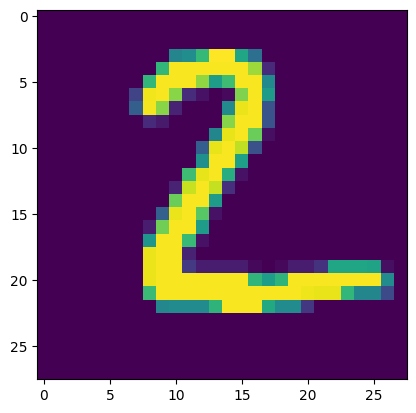

In [33]:
predict = model.predict(X_test[:1])
print(predict)
print(np.argmax(predict), np.argmax(y_test[0]))

plt.imshow(X_test[:1].reshape(28, 28))
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
[[0.09723917 0.10239574 0.10369115 0.10616471 0.09144442 0.10483902
  0.10262535 0.09588321 0.10097346 0.09474374]]
3 1


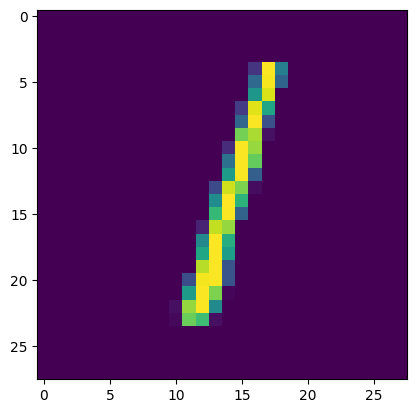

In [37]:
model.save_weights('cnn.weights.h5')
model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(units=10, activation='softmax'))
model.load_weights('cnn.weights.h5')
predict = model.predict(X_test[1:2])
print(predict)
print(np.argmax(predict), np.argmax(y_test[1]))

plt.imshow(X_test[1:2].reshape(28, 28))
plt.show()
